# Crop Yield Prediction MVP
Let's build a quick baseline model for predicting crop yields based on some historical data we found (weather, pesticides, etc). Also need to clean up the data first since it's a bit messy.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Column Standardization
Just stripping whitespace from column names to make them easier to work with.

In [8]:
def standardize_columns(df):
    df.columns = df.columns.astype(str).str.strip()
    return df

yield_df = standardize_columns(pd.read_csv('raw_data/yield.csv'))
pesticides_df = standardize_columns(pd.read_csv('raw_data/pesticides.csv'))
rainfall_df = standardize_columns(pd.read_csv('raw_data/rainfall.csv'))
temp_df = standardize_columns(pd.read_csv('raw_data/temp.csv'))

print("Yield Columns:", yield_df.columns.tolist())
print("Pesticides Columns:", pesticides_df.columns.tolist())
print("Rainfall Columns:", rainfall_df.columns.tolist())
print("Temperature Columns:", temp_df.columns.tolist())

Yield Columns: ['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']
Pesticides Columns: ['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value']
Rainfall Columns: ['Area', 'Year', 'average_rain_fall_mm_per_year']
Temperature Columns: ['year', 'country', 'avg_temp']


## 2 & 5. Schema Alignment & Feature Selection
Gotta rename some columns so they match (like country -> Area) and drop the weird Domain/Element columns we don't need.

In [9]:
# yield: keep Area, Item, Year, Value -> hg/ha_yield
yield_df = yield_df[['Area', 'Item', 'Year', 'Value']].copy()
yield_df.rename(columns={'Value': 'hg/ha_yield'}, inplace=True)

# pesticides: rename column
pesticides_df = pesticides_df[['Area', 'Year', 'Value']].copy()
pesticides_df.rename(columns={'Value': 'pesticides_tonnes'}, inplace=True)

# rain: keep Area, Year, average_rain_fall_mm_per_year. fix non-numeric stuff.
rainfall_df['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall_df['average_rain_fall_mm_per_year'], errors='coerce')

# temp: rename country and year
temp_df.rename(columns={'country': 'Area', 'year': 'Year'}, inplace=True)
temp_df = temp_df[['Area', 'Year', 'avg_temp']].copy()


## Merge Datasets
Inner merge everything on Area and Year.

In [11]:
merged_df = yield_df.merge(rainfall_df, on=['Area', 'Year'], how='inner')
merged_df = merged_df.merge(pesticides_df, on=['Area', 'Year'], how='inner')
merged_df = merged_df.merge(temp_df, on=['Area', 'Year'], how='inner')

print("Merged Dataset Shape:", merged_df.shape)

Merged Dataset Shape: (28248, 7)


## 3. Drop Duplicates
Removing overlapping rows.

In [14]:
duplicates_count = merged_df.duplicated().sum()
print(f"Found {duplicates_count} duplicate rows.")

merged_df.drop_duplicates(inplace=True)
print("Shape after deduplication:", merged_df.shape)

Found 2310 duplicate rows.
Shape after deduplication: (25938, 7)


## 4. Missing Values
Filling missing numericals with the median. Simple but it works.

In [16]:
print("Null values before imputation:\n", merged_df.isnull().sum())

numeric_cols = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
for col in numeric_cols:
    median_val = merged_df[col].median()
    merged_df[col] = merged_df[col].fillna(median_val)

print("\nNull values after median imputation:\n", merged_df.isnull().sum())

Null values before imputation:
 Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    6
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Null values after median imputation:
 Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


## Outliers
Drop anomalies using IQR method on the yield target.

In [18]:
Q1 = merged_df['hg/ha_yield'].quantile(0.25)
Q3 = merged_df['hg/ha_yield'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

merged_df = merged_df[(merged_df['hg/ha_yield'] >= lower_bound) & (merged_df['hg/ha_yield'] <= upper_bound)]
print("Shape after IQR outlier removal:", merged_df.shape)

Shape after IQR outlier removal: (24020, 7)


## 6. Categorical Encoding
Label encoding Area and Item so the tree models can handle them without blowing up the feature space.

In [19]:
label_encoders = {}
categorical_cols = ['Area', 'Item']

for col in categorical_cols:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])
    label_encoders[col] = le

print("Head after encoding:")
print(merged_df.head())

Head after encoding:
   Area  Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0     0     1  1990        36613                         1485.0   
1     0     1  1991        29068                         1485.0   
2     0     1  1992        24876                         1485.0   
3     0     1  1993        24185                         1485.0   
4     0     1  1994        25848                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     15.36  
2              121.0     16.06  
3              121.0     16.05  
4              201.0     16.96  


## 7. Scaling and Splitting
Standard scaling numericals (not the label encoded ones) and doing a standard 80/20 train test split.

In [23]:
X = merged_df.drop(columns=['hg/ha_yield'])
y = merged_df['hg/ha_yield']

# scale numericals only
scaler = StandardScaler()
X[numeric_cols + ['Year']] = scaler.fit_transform(X[numeric_cols + ['Year']])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Training Models

In [25]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.4f}\n")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [26]:
# baseline LR model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_metrics = evaluate_model("Linear Regression", y_test, y_pred_lr)

--- Linear Regression ---
MAE:  42668.33
RMSE: 53312.45
R2:   0.0459



In [29]:
# Decision tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_metrics = evaluate_model("Decision Tree", y_test, y_pred_dt)

--- Decision Tree ---
MAE:  3672.02
RMSE: 11123.46
R2:   0.9585



In [31]:
# Random forest model
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)

--- Random Forest ---
MAE:  3253.07
RMSE: 7684.95
R2:   0.9802



## Feature Importance
Let's see what features the Random Forest thought were most important.

In [33]:
# extract importances
importances = rf_model.feature_importances_

# create df for plot
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                         Feature  Importance
1                           Item    0.648361
4              pesticides_tonnes    0.100244
3  average_rain_fall_mm_per_year    0.082424
0                           Area    0.074468
5                       avg_temp    0.067544
2                           Year    0.026959


/var/folders/0_/9b2pn0cj0q10l4d_22zpbkjr0000gn/T/ipykernel_35892/3946403587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


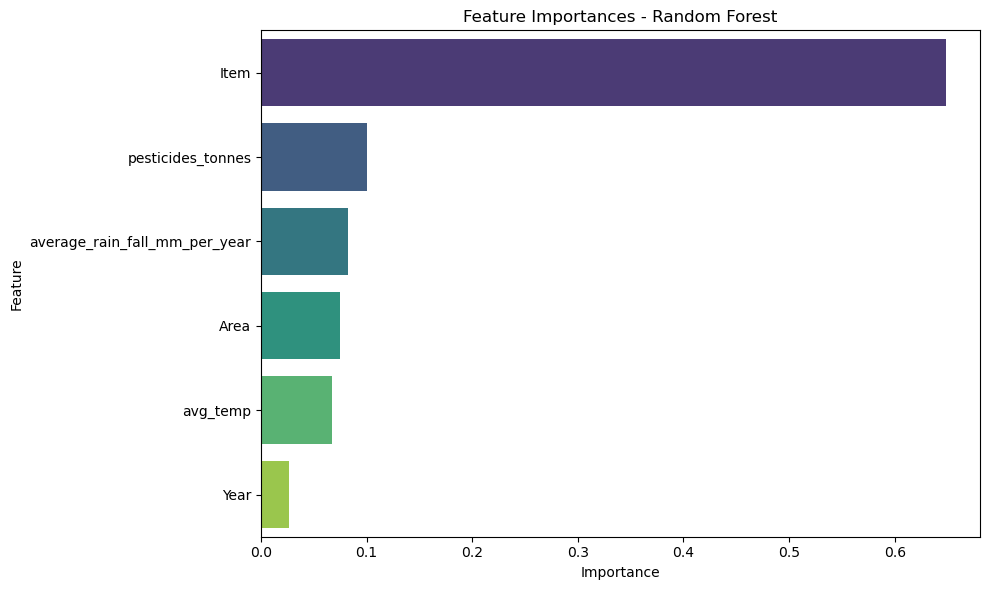

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## 9. Save Models
Dump the models and transformers so we can load them into the web app.

In [37]:
# save rf model and preprocessing stuff
joblib.dump(rf_model, 'crop_yield_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Artifacts saved: crop_yield_rf_model.pkl, scaler.pkl, label_encoders.pkl")

Artifacts saved: crop_yield_rf_model.pkl, scaler.pkl, label_encoders.pkl
